In [24]:
%pip install pandas numpy matplotlib seaborn scikit-learn joblib streamlit

  Using cached altair-6.2.2-py3-none-any.whl.metadata (11 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached pydeck-0.9.3-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached pyarrow-24.0.0-cp314-cp314-win_amd64.whl.metadata (3.0 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached starlette-1.3.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached uvicorn-0.51.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached httptools-0.8.0-cp314-cp314-win_amd64.whl.metadata (3.7 kB)
  Using cached anyio-4.14.2-py3-none-any.whl.metadata (4.6 kB)
  Using cached python_multipart-0.0.32-py3-none-any.whl.metadata (2.1 kB)
  Using cached websockets-16.1.1-cp314-cp314-win_amd64


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# --------------------- Importing Labraries -------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
# ----------<<< Load dataset >>>-----------
df = pd.read_csv("loan_data.csv")

# ----------<<< Data understanding >>>------------
print("<<<<<<<<<<<<------------ First 10 Rows -------------->>>>>>>>>>>>\n")
print(df.head(10))

print("\n<<<<<<<<--------- Dataset Shape --------->>>>>>>>>>")
print(df.shape)

print("\n<<<<<<<<<--------- Column Names --------->>>>>>>>>>>\n")
print(df.columns)

print("\n<<<<<<<<<<------------ Dataset Information ------------->>>>>>>>>>>>>\n")
df.info()

print("\n<<<<<<<<<--------- Statistical Summary ---------->>>>>>>>>>\n")
print(df.describe())

print("\n::::::: Target Variable Distribution :::::::\n")
print(df["Loan_Status"].value_counts())

df.columns = df.columns.str.strip()

<<<<<<<<<<<<------------ First 10 Rows -------------->>>>>>>>>>>>

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001003   Male     Yes          1      Graduate            No   
1  LP001005   Male     Yes          0      Graduate           Yes   
2  LP001006   Male     Yes          0  Not Graduate            No   
3  LP001008   Male      No          0      Graduate            No   
4  LP001013   Male     Yes          0  Not Graduate            No   
5  LP001024   Male     Yes          2      Graduate            No   
6  LP001027   Male     Yes          2      Graduate           NaN   
7  LP001029   Male      No          0      Graduate            No   
8  LP001030   Male     Yes          2      Graduate            No   
9  LP001032   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             4583             1508.0       128.0             360.0   
1             3000             

In [4]:
# ---------------- Missing values ------------------
print("\n:::::::::::::::: Missing Values Before Cleaning :::::::::::::::::\n")
print(df.isnull().sum())

# Remove rows with missing target values
df.dropna(
    subset=["Loan_Status"],
    inplace=True
)

# Fill categorical columns with mode
categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Self_Employed",
    "Loan_Amount_Term",
    "Credit_History"
]
for column in categorical_columns:

    df[column] = df[column].fillna(
        df[column].mode()[0]
    )

# Fill numerical column with median
df["LoanAmount"] = df["LoanAmount"].fillna(
    df["LoanAmount"].median()
)

print("\n::::::::::: Missing Values After Cleaning :::::::::::::\n")
print(df.isnull().sum())



:::::::::::::::: Missing Values Before Cleaning :::::::::::::::::

Loan_ID               0
Gender                5
Married               0
Dependents            8
Education             0
Self_Employed        21
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     11
Credit_History       30
Property_Area         0
Loan_Status           0
dtype: int64

::::::::::: Missing Values After Cleaning :::::::::::::

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [5]:
# --------------- Remove duplicates ---------------
print("\nDuplicate Rows:")
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("\nDataset Shape After Removing Duplicates:")
print(df.shape)


Duplicate Rows:
0

Dataset Shape After Removing Duplicates:
(381, 13)


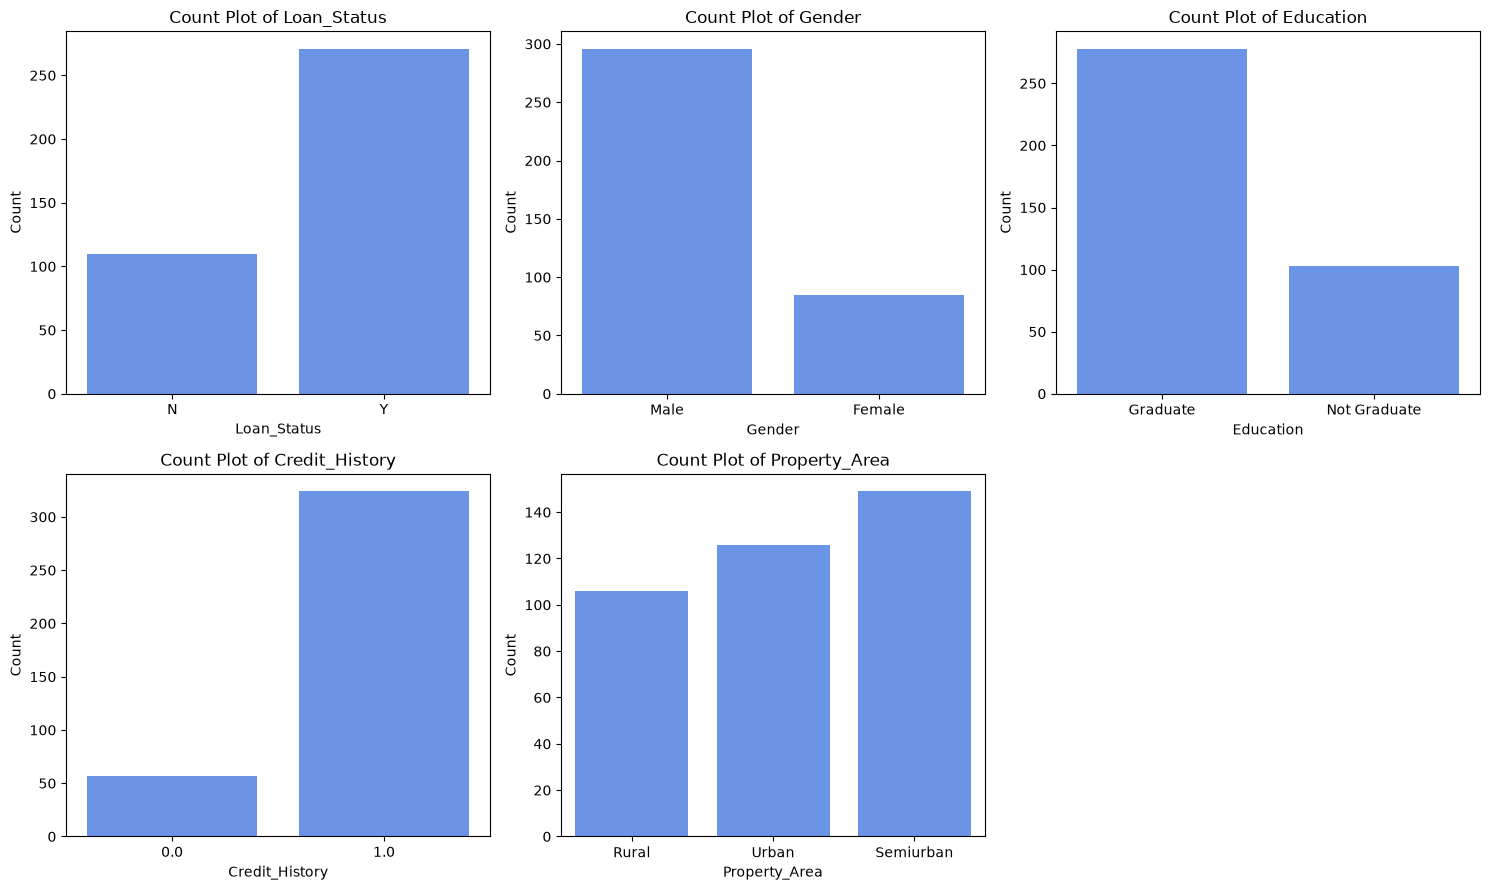

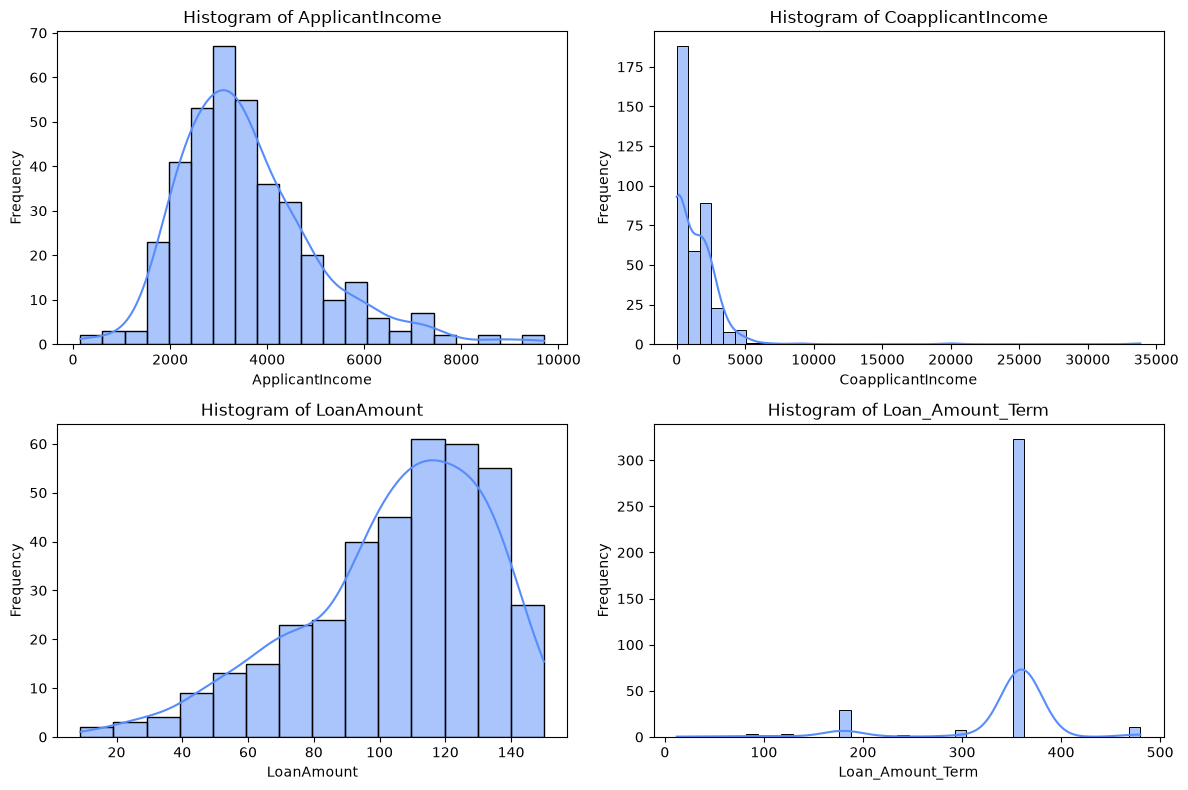

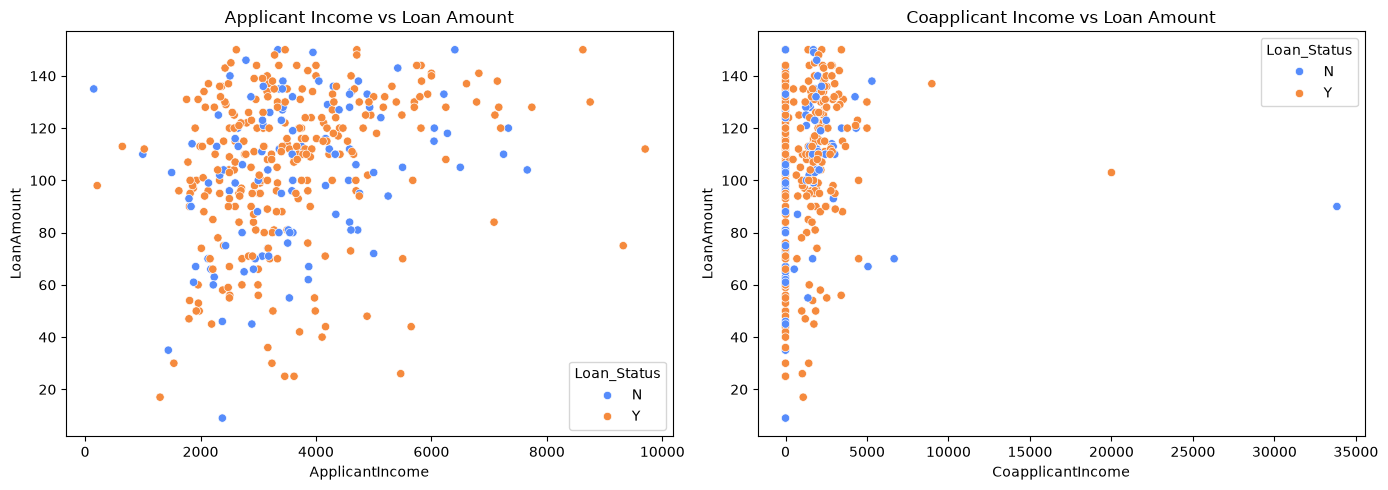

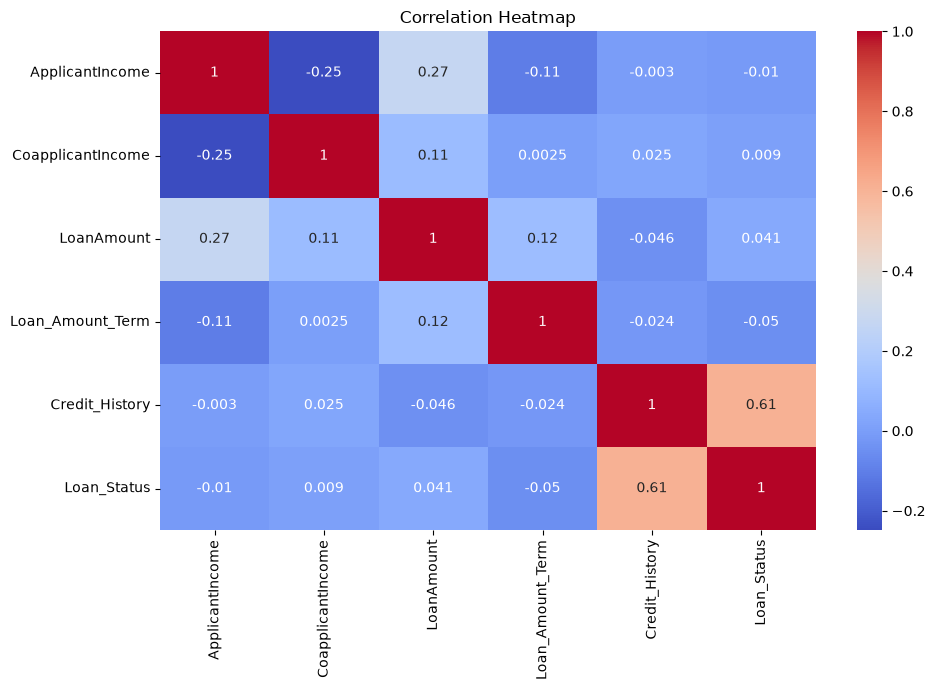

In [6]:
# EDA VISUALIZATION

# 1. COUNT PLOTS
# --------------------------------
categorical_columns = [
    "Loan_Status",
    "Gender",
    "Education",
    "Credit_History",
    "Property_Area"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for column, ax in zip(categorical_columns, axes.flat):
    sns.countplot(x=column, data=df, ax=ax)
    ax.set_title(f"Count Plot of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Count")

# Remove unused subplot
axes[1, 2].axis("off")
plt.tight_layout()
plt.show()

# 2. HISTOGRAM / HISTPLOT
# --------------------------------
numerical_columns = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for column, ax in zip(numerical_columns, axes.flat):
    sns.histplot(df[column], kde=True, ax=ax)
    ax.set_title(f"Histogram of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# 3. SCATTER PLOTS
# --------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x="ApplicantIncome", y="LoanAmount",
                hue="Loan_Status",
                ax=axes[0]
)
axes[0].set_title("Applicant Income vs Loan Amount")
sns.scatterplot(
    data=df,
    x="CoapplicantIncome",
    y="LoanAmount",
    hue="Loan_Status",
    ax=axes[1]
)
axes[1].set_title("Coapplicant Income vs Loan Amount")

plt.tight_layout()
plt.show()

# 5. CORRELATION HEATMAP
# --------------------------------
correlation_df = df.copy()
correlation_df["Loan_Status"] = (
    correlation_df["Loan_Status"]
    .map({
        "Y": 1,
        "N": 0
    })
)

numerical_data = (correlation_df.select_dtypes
                  (include=["int64", "float64"]))
plt.figure(figsize=(10, 7))
sns.heatmap(
    numerical_data.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [11]:
# --------------- Convert target variable -----------------
df["Loan_Status"] = df["Loan_Status"].map({
    "Y": 1,
    "N": 0
})

# ---------------- Separate features and target ---------------
X = df.drop(["Loan_Status", "Loan_ID"], axis=1)
y = df["Loan_Status"]

print("\n::::::::::: Features ::::::::::::\n")
print(X.columns)

print("\n::::::::::: Target :::::::::::::\n")
print(y.name)



::::::::::: Features ::::::::::::

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='str')

::::::::::: Target :::::::::::::

Loan_Status


In [8]:
# --------------------- One-hot encoding ------------------
categorical_columns = X.select_dtypes(include=["str"]).columns

print("\n::::::::::::: Categorical Columns :::::::::::::\n")
print(categorical_columns)

X_encoded = pd.get_dummies(X, columns=categorical_columns)
X_encoded = X_encoded.astype(int)

print("\n:::::::::::::::::: Encoded Dataset :::::::::::::::::::\n")
print(X_encoded.head())

print("\nEncoded Dataset Shape:\n")
print(X_encoded.shape)


::::::::::::: Categorical Columns :::::::::::::

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area'],
      dtype='str')

:::::::::::::::::: Encoded Dataset :::::::::::::::::::

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             4583               1508         128               360   
1             3000                  0          66               360   
2             2583               2358         120               360   
3             6000                  0         141               360   
4             2333               1516          95               360   

   Credit_History  Gender_Female  Gender_Male  Married_No  Married_Yes  \
0               1              0            1           0            1   
1               1              0            1           0            1   
2               1              0            1           0            1   
3               1              0            1         

In [9]:
print(":: Missing values:", y.isnull().sum())
print(y.value_counts())
print(y.unique())

:: Missing values: 0
Loan_Status
1    271
0    110
Name: count, dtype: int64
[0 1]


In [10]:
# ----------------- Train-test split ----------------
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.33,
    random_state=42,
    stratify=y
)

print("\n<<<<<<<<<<<<< Training and Testing Shapes >>>>>>>>>>>>>>>>\n")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


<<<<<<<<<<<<< Training and Testing Shapes >>>>>>>>>>>>>>>>

X_train: (255, 20)
X_test: (126, 20)
y_train: (255,)
y_test: (126,)


In [12]:
# ----------------------- Feature scaling -------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
# ------------- Model training --------------
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

print("\nModel Training Completed")
# -------- Predictions -----------
y_pred = model.predict(X_test_scaled)


Model Training Completed


In [17]:
# Evaluation
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:")
print(accuracy)

print("\nAccuracy Percentage:")
print(
    round(accuracy * 100, 2),
    "%"
)

print("\nClassification Report:")
print(classification_report(
        y_test,
        y_pred
    )
)


Model Accuracy:
0.8492063492063492

Accuracy Percentage:
84.92 %

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.47      0.64        36
           1       0.83      1.00      0.90        90

    accuracy                           0.85       126
   macro avg       0.91      0.74      0.77       126
weighted avg       0.88      0.85      0.83       126



In [18]:
# Confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[17 19]
 [ 0 90]]


In [22]:
# Save files
joblib.dump(model, "loan_approval_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X_encoded.columns.tolist(), "columns.pkl")

['columns.pkl']

In [23]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\umap\PycharmProjects\Loan Approval Prediction\Loan Approval Prediction
['columns.pkl', 'loan_approval_model.pkl', 'loan_data.csv', 'model traning.ipynb', 'scaler.pkl']
